In [97]:
##**CreditShield AI: Explainable Credit Risk Prediction System**##

In [ ]:
# Data Loading + Understanding + EDA #

In [ ]:
#Install CatBoost#

!pip install catboost

In [ ]:
# import libraries #

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
#Load datasets #

In [ ]:
from types import MemberDescriptorType
application = pd.read_csv('/content/application_train.csv')

test = pd.read_csv('/content/application_test.csv')

bureau = pd.read_csv('/content/bureau.csv')

previous = pd.read_csv('/content/previous_application.csv')

payments = pd.read_csv('/content/installments_payments.csv', low_memory=False)

credit = pd.read_csv('/content/credit_card_balance.csv')

In [ ]:
#Dataset Shapes#

In [ ]:
print("Application:", application.shape)
print("Test:", test.shape)
print("Bureau:", bureau.shape)
print("Previous:", previous.shape)
print("Payments:", payments.shape)
print("Credit Card:", credit.shape)

In [ ]:
application.head()

In [ ]:
application.info()

In [ ]:
#Missing Values#

In [ ]:
missing = application.isnull().sum()

missing = missing[missing>0]

missing.sort_values(ascending=False).head(20)

In [ ]:
#Duplicate Rows#

In [ ]:
application.duplicated().sum()

In [ ]:
## Target Distribution ##

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='TARGET', data=application)

plt.title("Default vs Non-Default")

plt.show()

In [ ]:
## Target Percentage ##

In [ ]:
application['TARGET'].value_counts(normalize=True)*100

In [ ]:
##Income Distribution ##

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(application['AMT_INCOME_TOTAL'],
bins=50)

plt.title("Income Distribution")

plt.show()

In [ ]:
## Credit Amount Distribution ##

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(application['AMT_CREDIT'],
bins=50)

plt.title("Loan Amount Distribution")

plt.show()

In [ ]:
## Age Distribution ##

In [ ]:
application['AGE'] = abs(application['DAYS_BIRTH'])/365

plt.figure(figsize=(8,5))

sns.histplot(application['AGE'],
bins=40)

plt.title("Customer Age Distribution")

plt.show()

In [ ]:
## Correlation with TARGET ##

In [ ]:
# Negative Correlation #
corr = application.corr(numeric_only=True)['TARGET']

corr.sort_values().head(10)

# Postive Correlation #
corr.sort_values(ascending=False).head(10)

# Key Observations

* The dataset contains customer demographic and loan-related information.
* The target variable is highly imbalanced, indicating fewer default cases compared to non-default cases.
* Income and loan amount distributions are positively skewed.
* Several variables contain missing values that require appropriate treatment.
* Some features exhibit stronger relationships with default risk and may significantly influence prediction performance.


In [ ]:
## 1.Repayment Discipline Index (RDI) ##

In [ ]:
## Average DPD (Days Past Due) ##

In [ ]:
## Convert columns to numeric ##
payments['DAYS_ENTRY_PAYMENT'] = pd.to_numeric(
    payments['DAYS_ENTRY_PAYMENT'],
    errors='coerce'
)

##Create DPD ##
payments['DPD'] = (
    payments['DAYS_ENTRY_PAYMENT']
    - payments['DAYS_INSTALMENT']
)

payments['DPD'] = payments['DPD'].clip(lower=0)

avg_dpd = (
    payments.groupby('SK_ID_CURR')['DPD']
    .mean()
    .reset_index()
)

avg_dpd.rename(
    columns={'DPD':'AVG_DPD'},
    inplace=True
)

In [ ]:
## Missed Installment Ratio ##

In [ ]:
payments['MISSED_PAYMENT'] = (
payments['AMT_PAYMENT'] < payments['AMT_INSTALMENT']
).astype(int)

missed_ratio = payments.groupby('SK_ID_CURR')['MISSED_PAYMENT'].mean().reset_index()

missed_ratio.rename(
columns={'MISSED_PAYMENT':'MISSED_PAYMENT_RATIO'},
inplace=True
)

In [ ]:
## 2.Credit Dependency Index (CDI)##

In [ ]:
## Average Credit Utilization ##

In [ ]:
credit['UTILIZATION'] = (
credit['AMT_BALANCE'] /
credit['AMT_CREDIT_LIMIT_ACTUAL']
)

credit_util = credit.groupby(
'SK_ID_CURR'
)['UTILIZATION'].mean().reset_index()

credit_util.rename(
columns={'UTILIZATION':'AVG_UTILIZATION'},
inplace=True
)

In [ ]:
## 3️. Existing Debt Features ##

In [ ]:
## Total Debt##
total_debt = bureau.groupby(
'SK_ID_CURR'
)['AMT_CREDIT_SUM_DEBT'].sum().reset_index()

total_debt.rename(
columns={'AMT_CREDIT_SUM_DEBT':'TOTAL_DEBT'},
inplace=True
)

## Active Loan Count ##
active_loans = bureau[
bureau['CREDIT_ACTIVE']=='Active'
]

active_loans = active_loans.groupby(
'SK_ID_CURR'
).size().reset_index(name='ACTIVE_LOAN_COUNT')

In [ ]:
## 4. Historical Reliability Score (HRS) ##

In [ ]:
## Previous Approved Loans ##
approved_loans = previous[
previous['NAME_CONTRACT_STATUS']=='Approved'
]

approved_count = approved_loans.groupby(
'SK_ID_CURR'
).size().reset_index(name='APPROVED_LOAN_COUNT')

## Previous Rejected Loans ##
rejected_loans = previous[
previous['NAME_CONTRACT_STATUS']=='Refused'
]

rejected_count = rejected_loans.groupby(
'SK_ID_CURR'
).size().reset_index(name='REJECTED_LOAN_COUNT')

In [ ]:
## 5️.Customer Stability Score (CSS) ##

In [ ]:
##Employment Years ##
application['EMPLOYMENT_YEARS'] = (
abs(application['DAYS_EMPLOYED'])/365
)

## Income Per Family Member ##
application['INCOME_PER_PERSON'] = (
application['AMT_INCOME_TOTAL'] /
application['CNT_FAM_MEMBERS']
)

## Debt-to-Income Ratio ##
application['DEBT_INCOME_RATIO'] = (
application['AMT_CREDIT'] /
application['AMT_INCOME_TOTAL']
)

In [ ]:
## Create CreditShield Master Dataset ##

In [ ]:
master_df = application.copy()

In [ ]:
## Merge Average DPD ##
master_df = master_df.merge(
    avg_dpd,
    on='SK_ID_CURR',
    how='left')

In [ ]:
#Merge Missed Payment Ratio#
master_df = master_df.merge(
    missed_ratio,
    on='SK_ID_CURR',
    how='left'
)

In [ ]:
#Merge Credit Utilization#
master_df = master_df.merge(
    credit_util,
    on='SK_ID_CURR',
    how='left'
)

In [ ]:
##Merge Total Debt##
master_df = master_df.merge(
    total_debt,
    on='SK_ID_CURR',
    how='left'
)

In [ ]:
## Merge Active Loan Count ##
master_df = master_df.merge(
    active_loans,
    on='SK_ID_CURR',
    how='left'
)

In [ ]:
##Merge Approved Loan Count##
master_df = master_df.merge(
    approved_count,
    on='SK_ID_CURR',
    how='left'
)

In [ ]:
#Merge Rejected Loan Count#
master_df = master_df.merge(
    rejected_count,
    on='SK_ID_CURR',
    how='left'
)

In [ ]:
#Dataset Shape#
master_df.shape

In [ ]:
#Missing Values#
master_df.isnull().sum().sort_values(
ascending=False
).head(20)

In [ ]:
#Fill Numeric Missing Values#
num_cols = master_df.select_dtypes(
include=np.number
).columns

master_df[num_cols] = master_df[
num_cols
].fillna(
master_df[num_cols].median()
)

In [ ]:
#Encode Categorical Variables#
master_df = pd.get_dummies(
master_df,
drop_first=True
)

In [ ]:
#Final Shape#
master_df.shape

In [ ]:
#Prepare X and y#
X = master_df.drop(
'TARGET',
axis=1
)

y = master_df['TARGET']

In [ ]:
#Train-Test Split#
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.isnull().sum().sum())

print(X_train.select_dtypes(include='object').columns)

In [ ]:
import numpy as np

print(np.isinf(X_train).sum().sum())
print(np.isinf(X_test).sum().sum())

## If output > 0 na, run:##
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [ ]:
## Model Competition ##

In [ ]:
##Import Models##
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

In [ ]:
#Logistic Regression#
lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_scaled, y_train_smote)

lr_pred = lr.predict(X_test_scaled)

lr_prob = lr.predict_proba(X_test_scaled)[:,1]

print("AUC ROC:", roc_auc_score(y_test, lr_prob))

In [ ]:
 #Random Forest#
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

print("AUC ROC:",
      roc_auc_score(y_test, rf_prob))

In [ ]:
# XGBoost #
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_smote, y_train_smote)

xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:,1]

print("AUC ROC:",
      roc_auc_score(y_test, xgb_prob))

In [ ]:
# LightGBM #
lgbm= LGBMClassifier(
    random_state=42
)
import re

X_train_smote.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in X_train_smote.columns
]

X_test.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in X_test.columns
]

lgbm.fit(X_train_smote, y_train_smote)

lgbm_prob = lgbm.predict_proba(X_test)[:,1]

print("AUC ROC:",
      roc_auc_score(y_test, lgbm_prob))

In [ ]:
#CatBoost#
cat = CatBoostClassifier(
    verbose=0,
    random_state=42
)

cat.fit(X_train_smote, y_train_smote)

cat_prob = cat.predict_proba(X_test)[:,1]

print("AUC ROC:",
      roc_auc_score(y_test, cat_prob))

In [ ]:
#Creating Comparison Table#
results = pd.DataFrame({

'Model':[
'Logistic Regression',
'Random Forest',
'XGBoost',
'LightGBM',
'CatBoost'
],

'AUC_ROC':[

roc_auc_score(y_test, lr_prob),

roc_auc_score(y_test, rf_prob),

roc_auc_score(y_test, xgb_prob),

roc_auc_score(y_test, lgbm_prob),

roc_auc_score(y_test, cat_prob)

]

})

results.sort_values(
by='AUC_ROC',
ascending=False
)

Model Comparison Summary:

Five machine learning models were trained and evaluated.

AUC-ROC was used as the primary metric.

Ensemble tree-based models
outperformed linear models.

The best-performing model will be selected for explainability and risk scoring.

In [ ]:
## Stacking Ensemble Model ##

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
estimators = [

('rf', RandomForestClassifier(
    n_estimators=200,
    random_state=42
)),

('xgb', XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)),

('lgbm', LGBMClassifier(
    random_state=42
))

]

In [ ]:
stack_model = StackingClassifier(

estimators=estimators,

final_estimator=LogisticRegression(),

cv=5

)

In [ ]:
stack_model.fit(
    X_train_smote,
    y_train_smote
)

In [ ]:
stack_pred = stack_model.predict(X_test)

stack_prob = stack_model.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score

print(
"Stacking AUC ROC:",
roc_auc_score(
y_test,
stack_prob
)
)

In [ ]:
from sklearn.metrics import precision_score

print(
"Precision:",
precision_score(
y_test,
stack_pred
)
)

In [ ]:
from sklearn.metrics import recall_score

print(
"Recall:",
recall_score(
y_test,
stack_pred
)
)

In [ ]:
from sklearn.metrics import f1_score

print(
"F1 Score:",
f1_score(
y_test,
stack_pred
)
)

##Stacking Ensemble Summary:

*Random Forest, XGBoost, and LightGBM were combined using a stacking ensemble approach.

*Logistic Regression was used as the meta-learner.

*The ensemble improved robustness and prediction performance.

*This approach reduces model variance and enhances generalization capability.

In [98]:
!pip install shap

In [99]:
#Import SHAP#
import shap

In [100]:
#Create Explainer
#If Stacking Model use pannirundha:
explainer = shap.Explainer(
    stack_model.predict,
    X_test
)

In [101]:
X_test = X_test.apply(pd.to_numeric, errors='coerce')
X_test = X_test.fillna(0).astype('float64')

explainer = shap.Explainer(
    stack_model.predict,
    X_test
)

In [102]:
print(X_test.dtypes)
print(X_test.shape)

SK_ID_CURR                        float64
CNT_CHILDREN                      float64
AMT_INCOME_TOTAL                  float64
AMT_CREDIT                        float64
AMT_ANNUITY                       float64
                                   ...   
WALLSMATERIAL_MODE_Others         float64
WALLSMATERIAL_MODE_Panel          float64
WALLSMATERIAL_MODE_Stone_brick    float64
WALLSMATERIAL_MODE_Wooden         float64
EMERGENCYSTATE_MODE_Yes           float64
Length: 237, dtype: object
(2327, 237)


In [96]:
#Calculate SHAP Values

shap_values = explainer(X_test)

PermutationExplainer explainer: 2328it [39:53,  1.03s/it]


/tmp/ipykernel_3069/2764575536.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


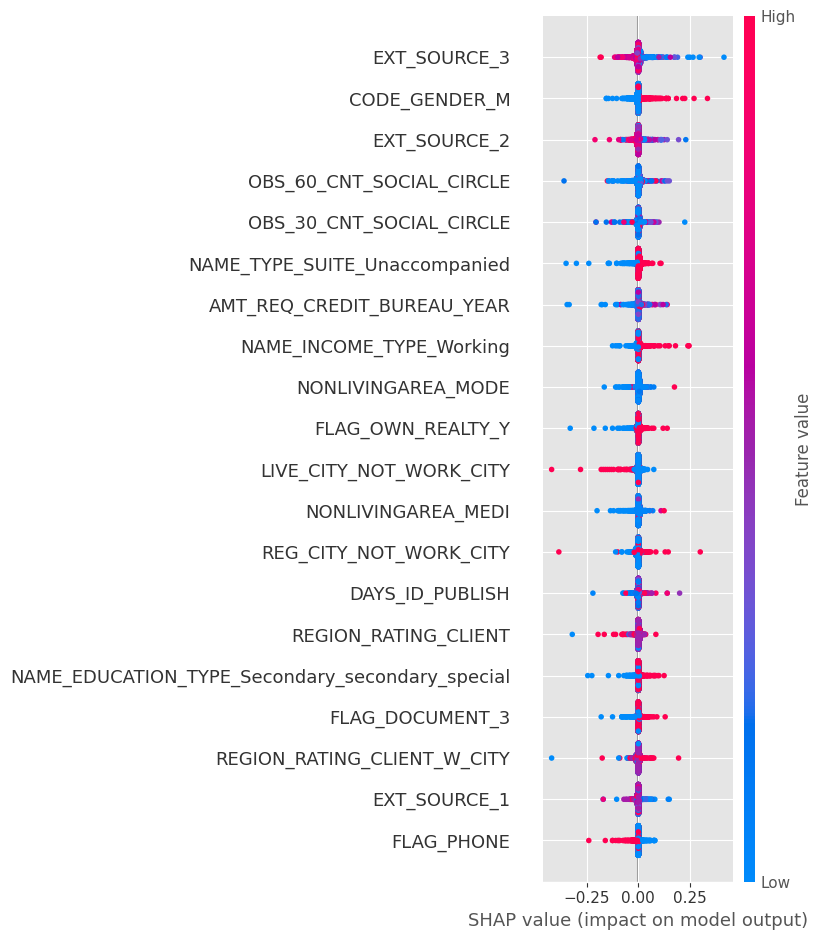

In [103]:
##SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test
)

#Insight;
Red color → High feature values
Blue color → Low feature values
Features on top → More important
Step 6

In [102]:
#Bar Plot of Feature Importance
shap.plots.bar(
    shap_values,
    max_display=15
)

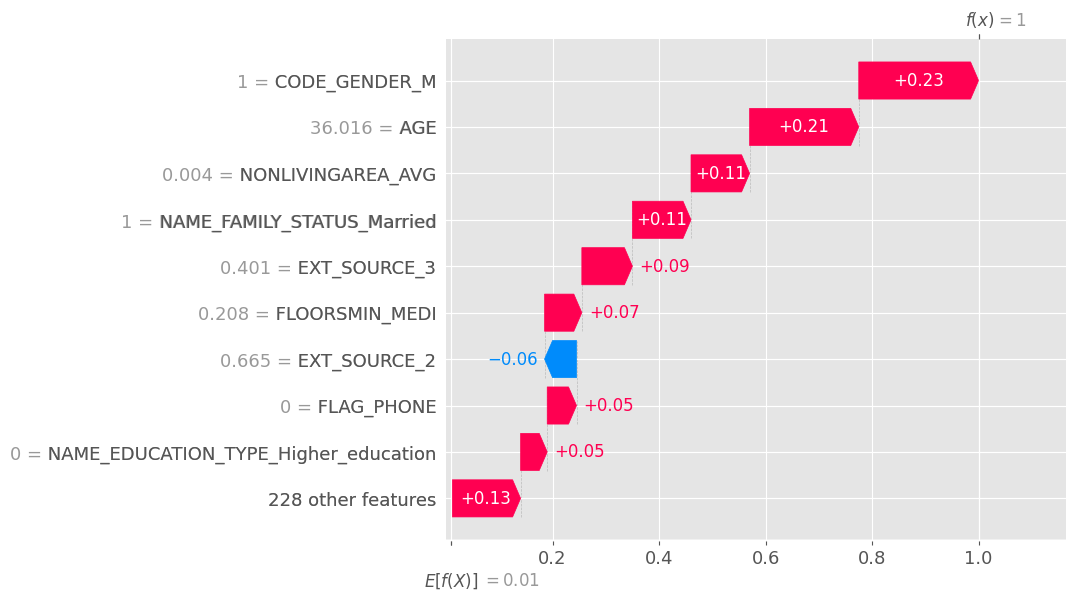

In [104]:
#Explain One Customer

#Example:

shap.plots.waterfall(
    shap_values[0]
)

#Explainable AI Summary

SHAP (SHapley Additive exPlanations) was used to interpret model predictions.

Feature importance analysis identified the key drivers of loan default.

Individual customer explanations were generated to improve model transparency.

Explainability enhances trust and supports business decision-making.

In [105]:
default_probability = stack_model.predict_proba(X_test)[:,1]

In [106]:
#Create CreditShield Score (0–100)

#Higher score = More risky

credit_score = default_probability * 100

In [107]:
risk_df = pd.DataFrame({

'Actual_Default': y_test.values,

'Default_Probability': default_probability,

'CreditShield_Score': credit_score

})

In [108]:
def assign_persona(score):

    if score <= 20:
        return 'Reliable Borrowers'

    elif score <= 50:
        return 'New Credit Seekers'

    elif score <= 75:
        return 'Credit Stressed Customers'

    else:
        return 'Potential Defaulters'

In [109]:
risk_df['Risk_Persona'] = risk_df[
    'CreditShield_Score'
].apply(assign_persona)

In [110]:
risk_df.head()

,Actual_Default,Default_Probability,CreditShield_Score,Risk_Persona
0,0,0.507338,50.733821,Credit Stressed Customers
1,0,0.137957,13.795710,Reliable Borrowers
2,0,0.030856,3.085642,Reliable Borrowers
3,0,0.037418,3.741834,Reliable Borrowers
4,0,0.094848,9.484826,Reliable Borrowers


In [111]:
risk_df['Risk_Persona'].value_counts()

,count
Risk_Persona,
Reliable Borrowers,2184
New Credit Seekers,112
Credit Stressed Customers,25
Potential Defaulters,6


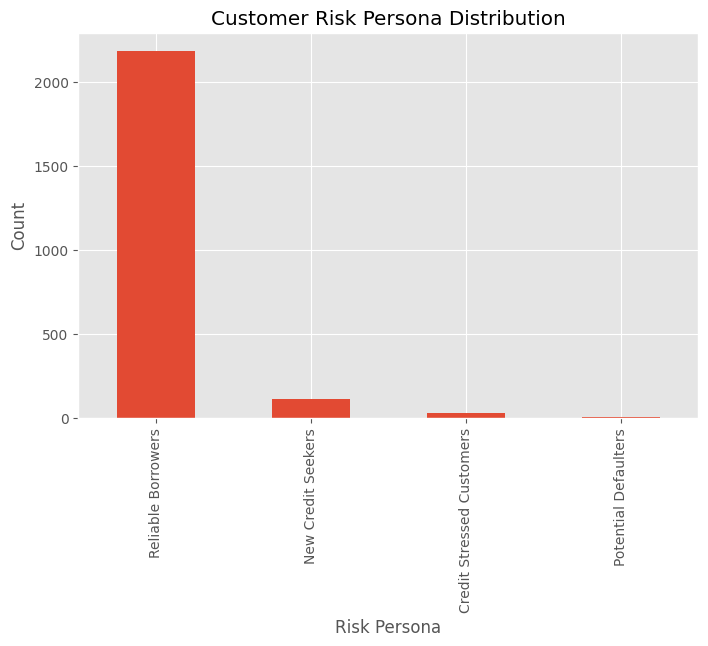

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

risk_df['Risk_Persona'].value_counts().plot(
    kind='bar'
)

plt.title(
'Customer Risk Persona Distribution'
)

plt.xlabel(
'Risk Persona'
)

plt.ylabel(
'Count'
)

plt.show()

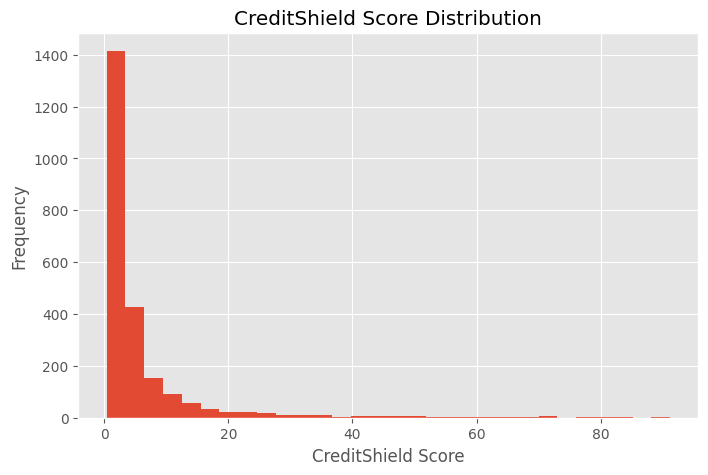

In [113]:
#CreditShield Score Distribution
plt.figure(figsize=(8,5))

plt.hist(
risk_df['CreditShield_Score'],
bins=30
)

plt.title(
'CreditShield Score Distribution'
)

plt.xlabel(
'CreditShield Score'
)

plt.ylabel(
'Frequency'
)

plt.show()

#Risk Persona Summary

Customers were categorized into four distinct personas based on their predicted default probabilities.

A CreditShield Score ranging from 0 to 100 was developed to quantify customer risk.

Reliable Borrowers represent low-risk customers.

Potential Defaulters represent high-risk customers requiring additional verification.

These personas support targeted lending strategies and improve decision-making.

In [114]:
#If XGBoost is your best model:
importance = pd.DataFrame({

'Feature':X_train.columns,

'Importance':xgb.feature_importances_

})

In [115]:
importance = importance.sort_values(
by='Importance',
ascending=False
)

importance.head(15)

,Feature,Importance
16,FLAG_PHONE,0.050214
80,FLAG_DOCUMENT_3,0.046596
74,OBS_30_CNT_SOCIAL_CIRCLE,0.042183
26,REG_CITY_NOT_WORK_CITY,0.042113
117,CODE_GENDER_M,0.037579
131,NAME_EDUCATION_TYPE_Higher education,0.032436
135,NAME_EDUCATION_TYPE_Secondary / secondary special,0.030148
125,NAME_TYPE_SUITE_Unaccompanied,0.029245
19,REGION_RATING_CLIENT,0.024169
58,NONLIVINGAREA_MODE,0.022543


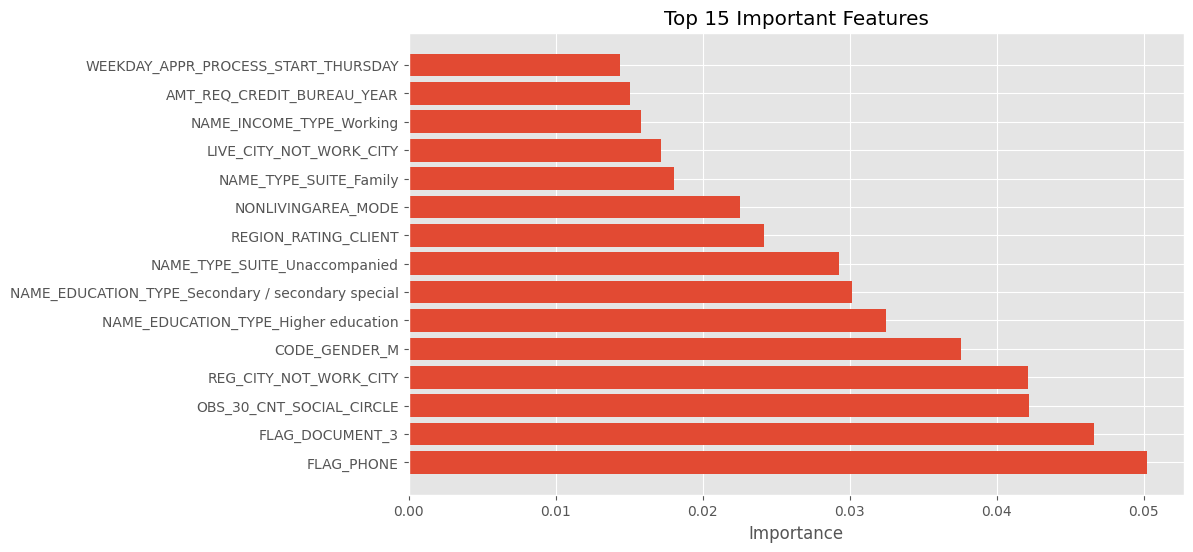

In [116]:
plt.figure(figsize=(10,6))

plt.barh(

importance['Feature'].head(15),

importance['Importance'].head(15)

)

plt.title(
'Top 15 Important Features'
)

plt.xlabel(
'Importance'
)

plt.show()

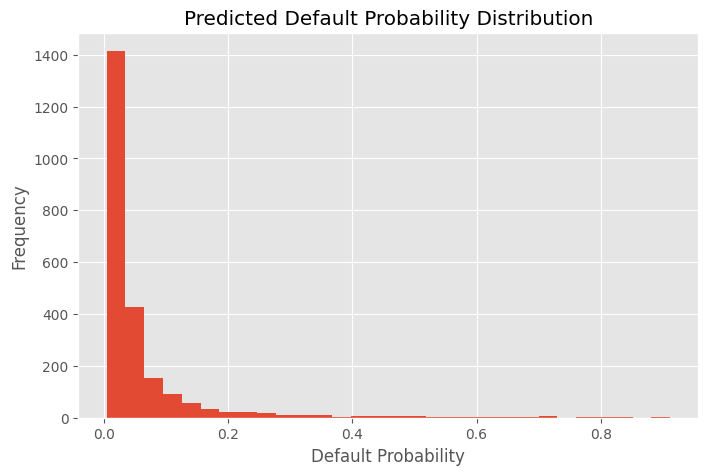

In [118]:
#Default Probability Distribution
plt.figure(figsize=(8,5))

plt.hist(
default_probability,
bins=30
)

plt.title(
'Predicted Default Probability Distribution'
)

plt.xlabel(
'Default Probability'
)

plt.ylabel(
'Frequency'
)
plt.show()

## Key Business Insights

- Customers with high debt and delayed payments exhibit higher default risk.
- Previous loan behavior significantly influences future repayment patterns.
- Credit utilization is a strong indicator of financial stress.
- Ensemble learning improves predictive performance.
- Explainable AI provides transparency and trust in decision-making.


## Business Recommendations

### Reliable Borrowers
- Faster loan approval.
- Premium offers and loyalty benefits.

### New Credit Seekers
- Moderate loan limits.
- Continuous monitoring.

### Credit Stressed Customers
- Additional document verification.
- Lower credit exposure.

### Potential Defaulters
- Strict eligibility checks.
- Risk-based pricing policies.

## Conclusion

This project developed an explainable credit risk prediction framework called CreditShield AI using the Home Credit Default Risk dataset.

The framework incorporated advanced feature engineering, multiple machine learning algorithms, stacking ensemble techniques, SHAP-based explainability, and customer risk personas. A custom CreditShield Score (0–100) was introduced to classify customers into Reliable Borrowers, New Credit Seekers, Credit Stressed Customers, and Potential Defaulters.

The proposed system enables financial institutions to identify risky customers early, improve loan approval decisions, and enhance portfolio management through interpretable and business-oriented analytics.